<a href="https://colab.research.google.com/github/vastav03/Machine-Learning-Practical/blob/main/Decision%20Tree%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np  # numeric arrays
import pandas as pd  # organise data into a table
import matplotlib.pyplot as plt  # plot graphs
from sklearn.model_selection import train_test_split  # split data
from sklearn.tree import DecisionTreeClassifier, plot_tree  # the model + tree visualiser
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # evaluation


In [ ]:
from google.colab import files  # Colab's file-upload helper
uploaded = files.upload()  # opens a Choose File dialog; pick Iris.csv

df = pd.read_csv('Iris.csv')  # load the CSV into a DataFrame
df.head()  # show first 5 rows to check the data


Saving Iris.csv to Iris.csv


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


(150, 5)
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


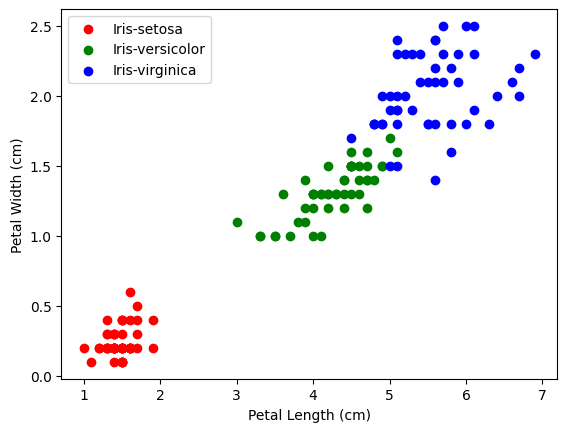

In [ ]:
df = df.drop(columns=['Id'])  # the Id column carries no useful information
print(df.shape)  # (rows, columns)
print(df['Species'].value_counts())  # how many samples per class

colors = {'Iris-setosa':'red', 'Iris-versicolor':'green', 'Iris-virginica':'blue'}
for sp, c in colors.items():  # plot each species in its own colour
    subset = df[df['Species'] == sp]
    plt.scatter(subset['PetalLengthCm'], subset['PetalWidthCm'], label=sp, color=c)
plt.xlabel('Petal Length (cm)'); plt.ylabel('Petal Width (cm)')
plt.legend(); plt.show()


In [ ]:
X = df.drop(columns=['Species'])  # all 4 measurement columns
y = df['Species']  # target: the species name

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)  # stratify keeps class balance equal
print(X_train.shape, X_test.shape)


(120, 4) (30, 4)


In [ ]:
model = DecisionTreeClassifier(criterion='entropy',  # split using Information Gain
                                max_depth=3, random_state=42)  # limit depth to avoid overfitting
model.fit(X_train, y_train)  # train the tree — no scaling needed!
print(dict(zip(X.columns, model.feature_importances_)))  # which features mattered most


{'SepalLengthCm': np.float64(0.0), 'SepalWidthCm': np.float64(0.0), 'PetalLengthCm': np.float64(0.6865462442276157), 'PetalWidthCm': np.float64(0.3134537557723843)}


In [ ]:
y_pred = model.predict(X_test)  # predict species for unseen test data
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
print('Accuracy:', acc)
print('Confusion Matrix:\n', cm)
print(classification_report(y_test, y_pred))


Accuracy: 0.9666666666666667
Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



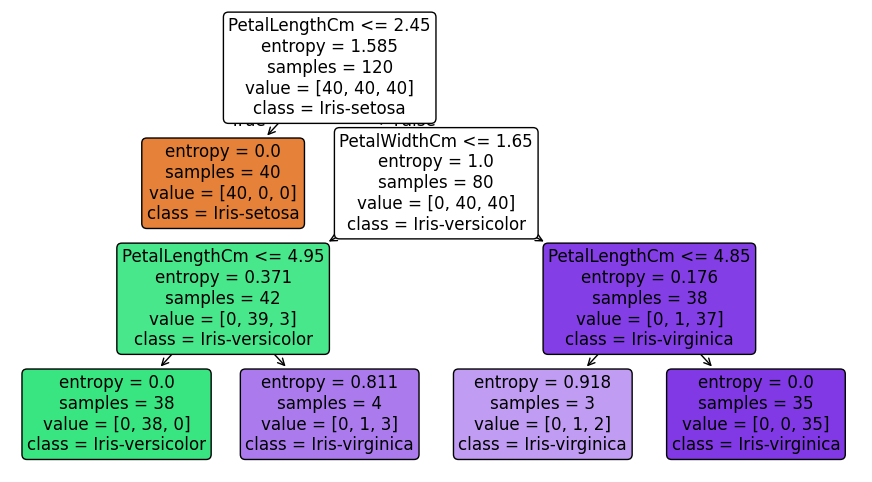

In [ ]:
plt.figure(figsize=(11, 6))
plot_tree(model, feature_names=X.columns,  # draw the tree with feature/class names
          class_names=model.classes_, filled=True, rounded=True)
plt.show()


In [ ]:
new_flower = pd.DataFrame([[5.8, 2.7, 4.1, 1.0]],  # Sepal 5.8x2.7, Petal 4.1x1.0
                          columns=X.columns)
pred = model.predict(new_flower)  # no scaling needed for a tree
print('Predicted species:', pred[0])


Predicted species: Iris-versicolor
